In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/uac_cleaned.csv')
print("Rows:", len(df))
print(df.head())

Rows: 1061
         Date  CBP_Apprehended  CBP_InCustody  Transferred_To_HHS  HHS_Care  \
0  2023-01-26            20.75          27.75                33.5    7521.5   
1  2023-01-27            21.50          33.50                26.0    7505.0   
2  2023-01-28            22.25          39.25                18.5    7488.5   
3  2023-01-29            23.00          45.00                11.0    7472.0   
4  2023-01-30            34.00          54.00                29.0    7743.0   

   HHS_Discharged   lag_1   lag_7  lag_14  rolling_7_mean  rolling_14_mean  \
0          210.75  7538.0  6955.2  6566.0     7281.671429      7035.035714   
1          241.50  7521.5  7010.8  6621.6     7352.271429      7098.135714   
2          272.25  7505.0  7066.4  6677.2     7412.571429      7156.085714   
3          303.00  7488.5  7122.0  6732.8     7462.571429      7208.885714   
4          196.00  7472.0  7280.0  6788.4     7528.714286      7277.071429   

   rolling_7_std  net_pressure  day_of_week  

In [3]:
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 1061 entries, 0 to 1060
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                1061 non-null   str    
 1   CBP_Apprehended     1061 non-null   float64
 2   CBP_InCustody       1061 non-null   float64
 3   Transferred_To_HHS  1061 non-null   float64
 4   HHS_Care            1061 non-null   float64
 5   HHS_Discharged      1061 non-null   float64
 6   lag_1               1061 non-null   float64
 7   lag_7               1061 non-null   float64
 8   lag_14              1061 non-null   float64
 9   rolling_7_mean      1061 non-null   float64
 10  rolling_14_mean     1061 non-null   float64
 11  rolling_7_std       1061 non-null   float64
 12  net_pressure        1061 non-null   float64
 13  day_of_week         1061 non-null   int64  
 14  month               1061 non-null   int64  
 15  week_of_year        1061 non-null   int64  
dtypes: float64(12), i

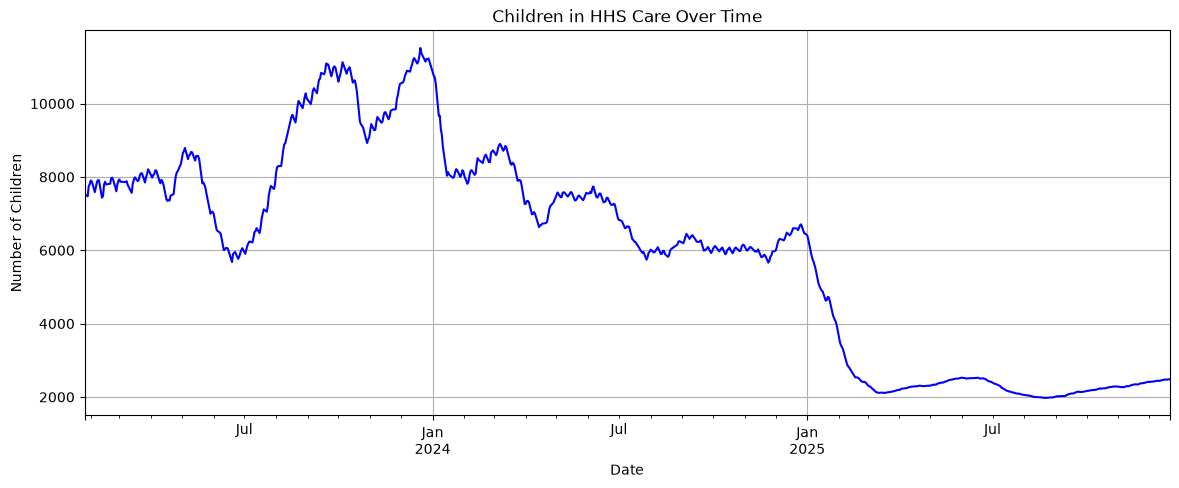

In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df['HHS_Care'].plot(figsize=(14,5), title='Children in HHS Care Over Time', color='blue')
plt.ylabel('Number of Children')
plt.grid(True)
plt.show()

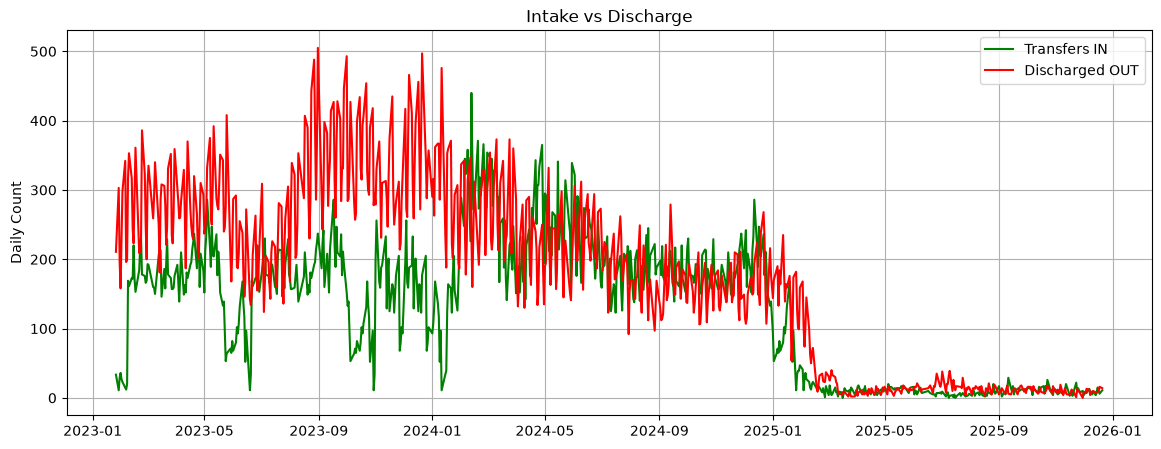

In [5]:
plt.figure(figsize=(14,5))
plt.plot(df.index, df['Transferred_To_HHS'], label='Transfers IN', color='green')
plt.plot(df.index, df['HHS_Discharged'], label='Discharged OUT', color='red')
plt.title('Intake vs Discharge')
plt.ylabel('Daily Count')
plt.legend()
plt.grid(True)
plt.show()

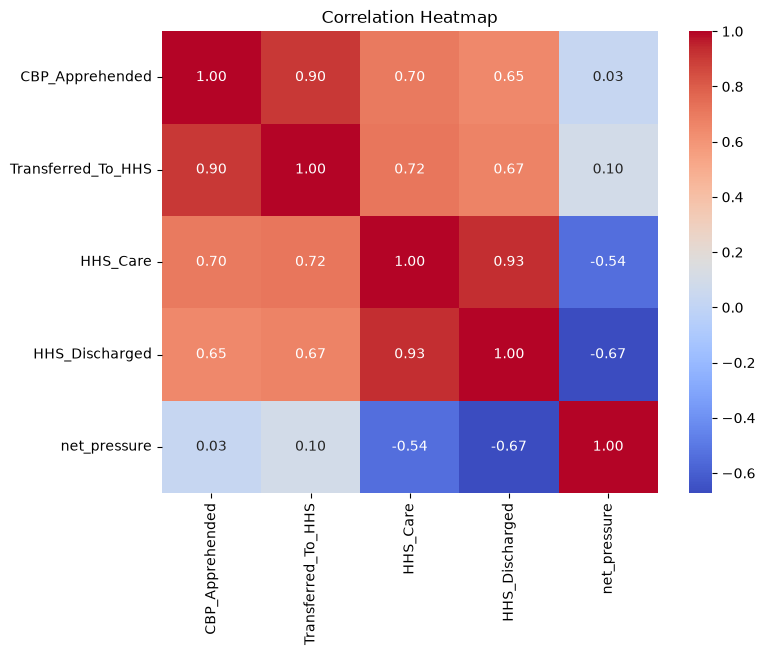

In [6]:
cols = ['CBP_Apprehended','Transferred_To_HHS','HHS_Care','HHS_Discharged','net_pressure']
plt.figure(figsize=(8,6))
sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

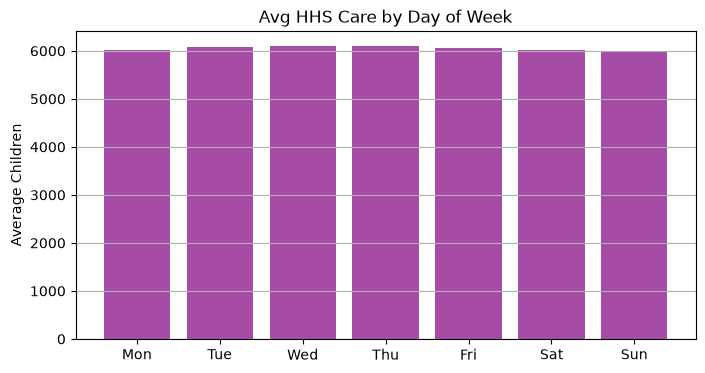

In [7]:
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_avg = df.groupby('day_of_week')['HHS_Care'].mean()
plt.figure(figsize=(8,4))
plt.bar(days, dow_avg.values, color='purple', alpha=0.7)
plt.title('Avg HHS Care by Day of Week')
plt.ylabel('Average Children')
plt.grid(True, axis='y')
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Features aur Target
features = ['lag_1','lag_7','lag_14','rolling_7_mean',
            'rolling_14_mean','net_pressure','day_of_week','month']

X = df[features]
y = df['HHS_Care']

# Time-based split (80% train, 20% test)
split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 848
Test size: 213


In [9]:
# Model train karo
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict karo
rf_pred = rf.predict(X_test)

# Accuracy check
mae  = mean_absolute_error(y_test, rf_pred)
rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
mape = np.mean(np.abs((y_test - rf_pred) / y_test)) * 100

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")
print(f"Accuracy: {100 - mape:.2f}%")

MAE  : 39.01
RMSE : 61.89
MAPE : 1.85%
Accuracy: 98.15%


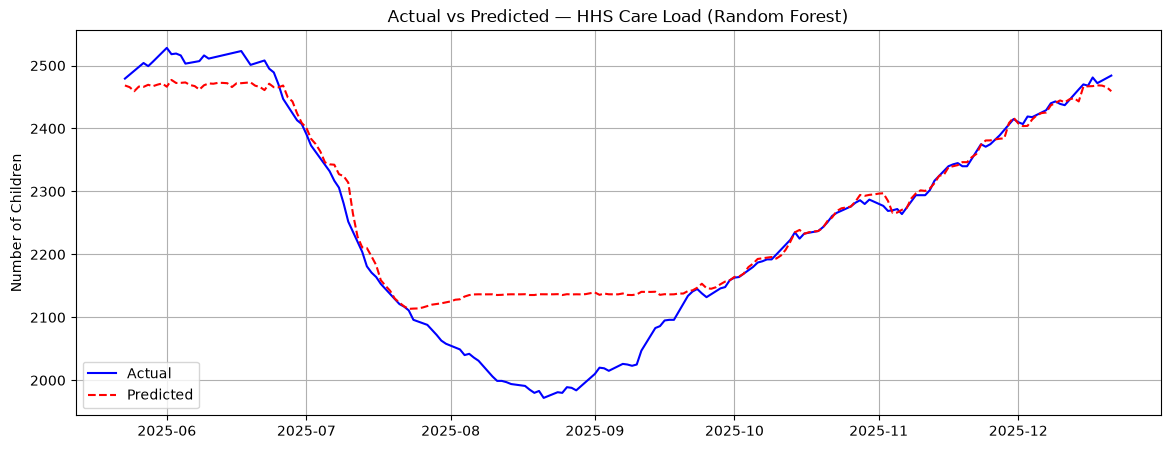

In [10]:
plt.figure(figsize=(14,5))
plt.plot(y_test.index, y_test.values, label='Actual', color='blue')
plt.plot(y_test.index, rf_pred, label='Predicted', color='red', linestyle='--')
plt.title('Actual vs Predicted — HHS Care Load (Random Forest)')
plt.ylabel('Number of Children')
plt.legend()
plt.grid(True)
plt.show()

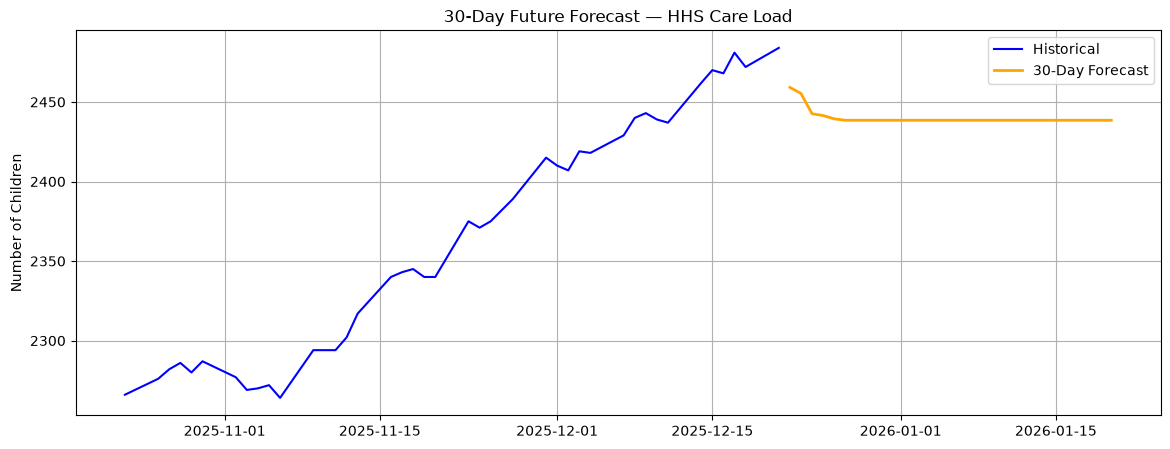

Forecasted values:
  2025-12-22 → 2459 children
  2025-12-23 → 2455 children
  2025-12-24 → 2443 children
  2025-12-25 → 2441 children
  2025-12-26 → 2439 children
  2025-12-27 → 2439 children
  2025-12-28 → 2439 children
  2025-12-29 → 2439 children
  2025-12-30 → 2439 children
  2025-12-31 → 2439 children
  2026-01-01 → 2439 children
  2026-01-02 → 2439 children
  2026-01-03 → 2439 children
  2026-01-04 → 2439 children
  2026-01-05 → 2439 children
  2026-01-06 → 2439 children
  2026-01-07 → 2439 children
  2026-01-08 → 2439 children
  2026-01-09 → 2439 children
  2026-01-10 → 2439 children
  2026-01-11 → 2439 children
  2026-01-12 → 2439 children
  2026-01-13 → 2439 children
  2026-01-14 → 2439 children
  2026-01-15 → 2439 children
  2026-01-16 → 2439 children
  2026-01-17 → 2439 children
  2026-01-18 → 2439 children
  2026-01-19 → 2439 children
  2026-01-20 → 2439 children


In [11]:
# Last row se future predict karo
last_row = df[features].iloc[-1].copy()
future_preds = []

for i in range(30):
    pred = rf.predict([last_row.values])[0]
    future_preds.append(pred)
    last_row['lag_14'] = last_row['lag_7']
    last_row['lag_7']  = last_row['lag_1']
    last_row['lag_1']  = pred

future_dates = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=30)

plt.figure(figsize=(14,5))
plt.plot(df.index[-60:], df['HHS_Care'].iloc[-60:], label='Historical', color='blue')
plt.plot(future_dates, future_preds, label='30-Day Forecast', color='orange', linewidth=2)
plt.title('30-Day Future Forecast — HHS Care Load')
plt.ylabel('Number of Children')
plt.legend()
plt.grid(True)
plt.show()

print("Forecasted values:")
for d, v in zip(future_dates, future_preds):
    print(f"  {d.date()} → {v:.0f} children")